# Necesidad de flota contra el plan

Flota multi-planta de Returnable Packaging Logistics (RPL) con movimientos MB51
sintéticos: 18 meses, 14 plantas, corte al 2026-06-30, plan de producción de las
12 semanas siguientes (2026-07-06 a 2026-09-27).

La pregunta de Fase 3: cuántos contenedores necesita cada empaque, por planta y
semana, para cubrir el plan, y cuánto cuesta en USD la brecha contra la flota
real (ADR-016).

Las cifras salen de los marts: `mart_necesidad_flota`, `mart_brecha_flota`,
`mart_red_prestamos` y `mart_sensibilidad_brecha`. Dos gráficas leen modelos
intermedios que dbt ya prueba: la flota proyectada por semana
(`int_flota_proyectada`) y la curva de z (`int_curva_z`). La fórmula vive en
la macro `necesidad_flota` (ADR-021, ADR-023); los costos, en
`int_tco_por_material` (ADR-010).

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import polars as pl
from IPython.display import Markdown, display

con = duckdb.connect("../data/rpi.duckdb", read_only=True)
IMG = Path("../docs/img")

COLOR = {"KLT": "#2c7fb8", "RACK": "#c0392b"}
GRIS = "#7f8c8d"
NOMBRE = {"KLT": "KLT", "RACK": "Rack"}
tipos = ["KLT", "RACK"]

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)


def q(sql: str) -> pl.DataFrame:
    # SUM() de BIGINT vuelve HUGEINT; Polars no lo lee como entero.
    df = con.execute(sql).pl()
    return df.with_columns(pl.col(pl.Int128).cast(pl.Int64), pl.col(pl.Decimal).cast(pl.Float64))


def usd(x: float, dec: int = 0) -> str:
    # En markdown de GitHub dos $ en un párrafo se leen como LaTeX.
    return f"\\${x:,.{dec}f}"


def millones(x: float) -> str:
    return f"\\${x / 1e6:,.2f}M"


def miles(x: float) -> str:
    return f"\\${x / 1e3:,.0f}k"

## 1. Necesidad contra flota

Necesidad = d_plan × ciclo + stock de seguridad, por planta, material y semana
(ADR-021). La flota proyectada es la del corte menos la merma pendiente (salidas
que la última conciliación todavía no reconoce) y menos lo que se pierde por
viaje del plan, merma y scrap (ADR-025).

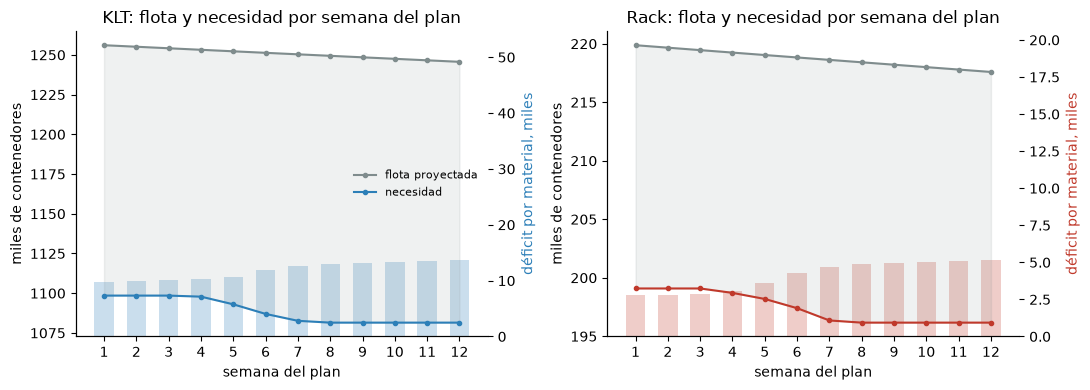

In [2]:
semanal = q("""
    SELECT f.tipo_material, f.semana,
           SUM(f.flota_proyectada)              AS flota,
           SUM(n.necesidad)::BIGINT             AS necesidad,
           SUM(f.merma_pendiente)               AS merma_pendiente,
           SUM(f.flota_corte)::BIGINT           AS flota_corte
    FROM int_flota_proyectada f
    JOIN mart_necesidad_flota n USING (planta, material, semana)
    GROUP BY ALL
    ORDER BY 1, 2
""")

# Déficit por material y semana: lo que la suma por tipo esconde.
deficit_semana = q("""
    SELECT f.tipo_material, f.semana,
           COUNT(*) FILTER (WHERE n.necesidad > f.flota_proyectada)               AS materiales,
           SUM(GREATEST(n.necesidad - f.flota_proyectada, 0))                     AS deficit
    FROM int_flota_proyectada f
    JOIN mart_necesidad_flota n USING (planta, material, semana)
    GROUP BY ALL
    ORDER BY 1, 2
""")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, k in zip(axes, tipos, strict=True):
    s = semanal.filter(pl.col("tipo_material") == k)
    d = deficit_semana.filter(pl.col("tipo_material") == k)
    sem = np.arange(1, s.height + 1)
    ax.plot(sem, s["flota"] / 1e3, color=GRIS, marker="o", ms=3, label="flota proyectada")
    ax.plot(sem, s["necesidad"] / 1e3, color=COLOR[k], marker="o", ms=3, label="necesidad")
    ax.fill_between(sem, s["necesidad"] / 1e3, s["flota"] / 1e3, color=GRIS, alpha=0.12)
    ax2 = ax.twinx()
    ax2.bar(
        sem, d["deficit"] / 1e3, color=COLOR[k], alpha=0.25, width=0.6, label="déficit por material"
    )
    ax2.set_ylim(0, d["deficit"].max() / 1e3 * 4)
    ax2.set_ylabel("déficit por material, miles", color=COLOR[k])
    ax2.spines["top"].set_visible(False)
    ax.set_title(f"{NOMBRE[k]}: flota y necesidad por semana del plan")
    ax.set_xlabel("semana del plan")
    ax.set_ylabel("miles de contenedores")
    ax.set_xticks(sem)
    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)
axes[0].legend(frameon=False, fontsize=8, loc="center right")
fig.tight_layout()
fig.savefig(IMG / "necesidad_vs_flota.png", dpi=150)
plt.show()

In [3]:
n1 = {
    r["tipo_material"]: r for r in semanal.group_by("tipo_material").first().iter_rows(named=True)
}
n12 = {
    r["tipo_material"]: r for r in semanal.group_by("tipo_material").last().iter_rows(named=True)
}
d1 = {
    r["tipo_material"]: r
    for r in deficit_semana.group_by("tipo_material").first().iter_rows(named=True)
}
d12 = {
    r["tipo_material"]: r
    for r in deficit_semana.group_by("tipo_material").last().iter_rows(named=True)
}

_lineas = []
for k in tipos:
    holgura = n12[k]["flota"] - n12[k]["necesidad"]
    _lineas.append(
        f"- {NOMBRE[k]}: necesidad de {n1[k]['necesidad']:,} contenedores en la semana 1 y "
        f"{n12[k]['necesidad']:,} en la 12. La flota proyectada baja de {n1[k]['flota']:,.0f} a "
        f"{n12[k]['flota']:,.0f}: sobran {holgura:,.0f} en total "
        f"({holgura * 100 / n12[k]['necesidad']:.1f}% de la necesidad). Aun así, material por "
        f"material, en la semana 1 quedan cortos {d1[k]['materiales']:,} ({d1[k]['deficit']:,.0f} "
        f"contenedores) y en la 12, {d12[k]['materiales']:,} ({d12[k]['deficit']:,.0f})."
    )
display(Markdown("\n".join(_lineas)))

- KLT: necesidad de 1,098,502 contenedores en la semana 1 y 1,081,483 en la 12. La flota proyectada baja de 1,256,103 a 1,245,651: sobran 164,168 en total (15.2% de la necesidad). Aun así, material por material, en la semana 1 quedan cortos 676 (9,705 contenedores) y en la 12, 786 (13,658).
- Rack: necesidad de 199,087 contenedores en la semana 1 y 196,168 en la 12. La flota proyectada baja de 219,874 a 217,588: sobran 21,420 en total (10.9% de la necesidad). Aun así, material por material, en la semana 1 quedan cortos 425 (2,778 contenedores) y en la 12, 538 (5,145).

La suma por tipo engaña: un KLT de sobra en PLNT_MX01 no cubre otro material
en PLNT_US03. La brecha se mide material por material y después se escala:
préstamo entre plantas con el mismo material, compra y desechable (ADR-025).

La necesidad baja a partir de la semana 4: los fines de serie (−50%) pesan más
que los arranques (+30%) en volumen, y los dos cambian en la semana 4 a 8
(ADR-022). El déficit por material se mueve al revés que la suma: lo empujan los
arranques.

## 2. La z se escoge por costo

El stock de seguridad usa z × σ del stock en uso. La z no es un número redondo:
sale de la razón crítica entre quedarse corto un día (desechable × factor de
quiebre / ciclo) y tener un contenedor de más un día (costo unitario × costo de
capital / 365). La curva mide, en el tramo de calibración, qué fracción de días
el stock en uso rebasó la necesidad con cada z; la escogida es la menor que
cumple el objetivo (ADR-025). El backtest la valida en las 13 semanas
siguientes, fuera de muestra.

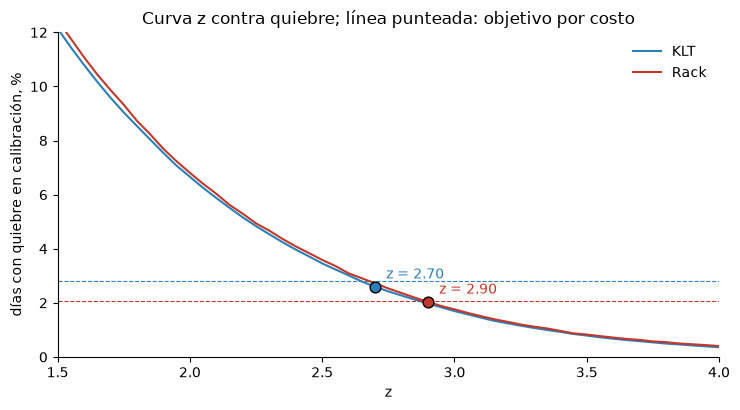

In [4]:
curva = q("SELECT tipo_material, z, quiebre FROM int_curva_z ORDER BY 1, 2")
sens = q("SELECT * FROM mart_sensibilidad_brecha")
base = {
    r["tipo_material"]: r for r in sens.filter(pl.col("escenario") == "base").iter_rows(named=True)
}

fig, ax = plt.subplots(figsize=(7.5, 4.2))
for k in tipos:
    c = curva.filter(pl.col("tipo_material") == k)
    ax.plot(c["z"], c["quiebre"] * 100, color=COLOR[k], label=NOMBRE[k])
    ax.axhline(base[k]["objetivo_quiebre"] * 100, color=COLOR[k], linestyle="--", linewidth=0.8)
    zq = c.filter(pl.col("z") == base[k]["z_servicio"])["quiebre"][0] * 100
    ax.scatter([base[k]["z_servicio"]], [zq], color=COLOR[k], s=60, edgecolors="black", zorder=3)
    ax.annotate(
        f"z = {base[k]['z_servicio']:.2f}",
        (base[k]["z_servicio"], zq),
        textcoords="offset points",
        xytext=(8, 6),
        color=COLOR[k],
    )
ax.set_xlim(1.5, 4.0)
ax.set_ylim(0, 12)
ax.set_xlabel("z")
ax.set_ylabel("días con quiebre en calibración, %")
ax.set_title("Curva z contra quiebre; línea punteada: objetivo por costo")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(IMG / "z_economica.png", dpi=150)
plt.show()

In [5]:
z3 = {
    r["tipo_material"]: r["necesidad_semana_1"]
    for r in sens.filter(pl.col("escenario") == "z_fija_3").iter_rows(named=True)
}
_lineas = []
for k in tipos:
    b = base[k]
    _lineas.append(
        f"- {NOMBRE[k]}: objetivo de {b['objetivo_quiebre'] * 100:.2f}% de días con quiebre; "
        f"la menor z que lo cumple es {b['z_servicio']:.2f}."
    )
_lineas.append(
    "- Con z = 3 fija la necesidad de la semana 1 sería "
    + " y ".join(f"{z3[k]:,} {NOMBRE[k]}" for k in tipos)
    + ", contra "
    + " y ".join(f"{base[k]['necesidad_semana_1']:,}" for k in tipos)
    + " con la z por costo."
)
display(Markdown("\n".join(_lineas)))

- KLT: objetivo de 2.79% de días con quiebre; la menor z que lo cumple es 2.70.
- Rack: objetivo de 2.07% de días con quiebre; la menor z que lo cumple es 2.90.
- Con z = 3 fija la necesidad de la semana 1 sería 1,140,675 KLT y 201,411 Rack, contra 1,098,502 y 199,087 con la z por costo.

### Piso de días de cobertura

La fórmula toma el mayor entre z × σ y los días de cobertura de política (KLT 3,
Rack 5, rango 2–7). Si el piso nunca manda, el supuesto no mueve nada.

In [6]:
ss = q("""
    SELECT tipo_material,
           COUNT(*)                                                    AS filas,
           MIN(stock_seguridad_dias)                                   AS minimo,
           QUANTILE_CONT(stock_seguridad_dias, 0.01)                   AS p01,
           MEDIAN(stock_seguridad_dias)                                AS mediana,
           COUNT(*) FILTER (WHERE stock_seguridad_dias <= 7)           AS en_rango_del_piso
    FROM mart_necesidad_flota
    GROUP BY 1
""")
s = {r["tipo_material"]: r for r in ss.iter_rows(named=True)}
piso_activo = sum(s[k]["en_rango_del_piso"] for k in tipos)
display(
    Markdown(
        " ".join(
            f"{NOMBRE[k]}: stock de seguridad mínimo de {s[k]['minimo']:.1f} días, mediana "
            f"{s[k]['mediana']:.1f}."
            for k in tipos
        )
        + f" Filas donde el piso de 7 días, el techo del rango, mandaría: {piso_activo} de "
        f"{ss['filas'].sum():,}. El supuesto de días de cobertura no mueve la necesidad en ningún "
        "punto de su rango; la variabilidad del sintético manda (ADR-021)."
    )
)

KLT: stock de seguridad mínimo de 8.3 días, mediana 16.6. Rack: stock de seguridad mínimo de 7.6 días, mediana 16.7. Filas donde el piso de 7 días, el techo del rango, mandaría: 0 de 80,352. El supuesto de días de cobertura no mueve la necesidad en ningún punto de su rango; la variabilidad del sintético manda (ADR-021).

## 3. Brecha por nivel de escalamiento

Tres niveles, en orden (ADR-016, ADR-025):

1. Préstamo entre plantas con el mismo material: primero dentro del país,
   después entre países, repartido en proporción al sobrante de cada donante.
2. Compra al corte de lo que el préstamo no cubre, en contenedores enteros.
   Llega con el lead time: KLT 4 semanas, Rack 12.
3. Desechable mientras la compra no llega.

Lo que sobra después de prestar es capital ocioso. La compra va en contenedores
enteros por material: por eso la barra pasa un poco del 100%.

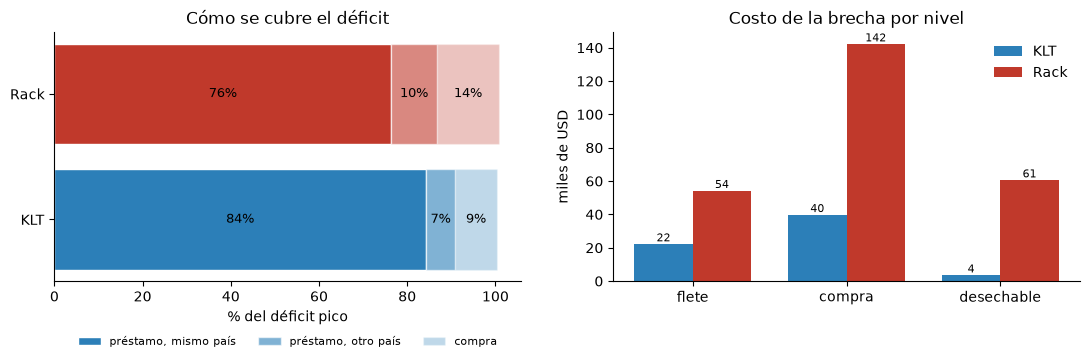

In [7]:
brecha = q("""
    SELECT tipo_material,
           COUNT(*) FILTER (WHERE deficit_pico > 0)        AS materiales,
           SUM(deficit_pico)                               AS deficit,
           SUM(recibido_mismo_pais)                        AS mismo_pais,
           SUM(recibido_otro_pais)                         AS otro_pais,
           SUM(compra)::BIGINT                             AS compra,
           COUNT(*) FILTER (WHERE compra > 0)              AS materiales_compra,
           SUM(viajes_desechable)                          AS viajes_desechable,
           SUM(usd_flete)                                  AS usd_flete,
           SUM(usd_compra)                                 AS usd_compra,
           SUM(usd_desechable)                             AS usd_desechable,
           SUM(sobrante_final)                             AS sobrante_final,
           SUM(usd_capital_ocioso)                         AS usd_capital_ocioso
    FROM mart_brecha_flota
    GROUP BY 1
    ORDER BY 1
""").with_columns(
    (pl.col("usd_flete") + pl.col("usd_compra") + pl.col("usd_desechable")).alias("usd_brecha")
)
b = {r["tipo_material"]: r for r in brecha.iter_rows(named=True)}

# Mismo concepto, misma cifra: el escenario base de la sensibilidad es este mart.
for k in tipos:
    assert abs(b[k]["usd_brecha"] - base[k]["usd_brecha"]) < 1, k
    assert b[k]["compra"] == base[k]["compra"], k

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
etapas = [
    ("mismo_pais", "préstamo, mismo país", 1.0),
    ("otro_pais", "préstamo, otro país", 0.6),
    ("compra", "compra", 0.3),
]
for i, k in enumerate(tipos):
    izq = 0.0
    for col, etiqueta, alfa in etapas:
        v = b[k][col] * 100 / b[k]["deficit"]
        ax1.barh(
            i,
            v,
            left=izq,
            color=COLOR[k],
            alpha=alfa,
            edgecolor="white",
            label=etiqueta if i == 0 else None,
        )
        if v > 4:
            ax1.text(izq + v / 2, i, f"{v:.0f}%", ha="center", va="center", fontsize=9)
        izq += v
ax1.set_yticks([0, 1], [NOMBRE[k] for k in tipos])
ax1.set_xlabel("% del déficit pico")
ax1.set_title("Cómo se cubre el déficit")
ax1.legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3)

componentes = [("usd_flete", "flete"), ("usd_compra", "compra"), ("usd_desechable", "desechable")]
x = np.arange(len(componentes))
ancho = 0.38
for j, k in enumerate(tipos):
    vals = [b[k][c] / 1e3 for c, _ in componentes]
    barras = ax2.bar(x + (j - 0.5) * ancho, vals, ancho, color=COLOR[k], label=NOMBRE[k])
    for barra, v in zip(barras, vals, strict=True):
        ax2.text(
            barra.get_x() + barra.get_width() / 2,
            v,
            f"{v:,.0f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )
ax2.set_xticks(x, [e for _, e in componentes])
ax2.set_ylabel("miles de USD")
ax2.set_title("Costo de la brecha por nivel")
ax2.legend(frameon=False)
fig.tight_layout()
fig.savefig(IMG / "brecha_escalamiento.png", dpi=150)
plt.show()

In [8]:
_cubre = (
    sum(b[k]["mismo_pais"] + b[k]["otro_pais"] for k in tipos)
    * 100
    / sum(b[k]["deficit"] for k in tipos)
)
usd_brecha = sum(b[k]["usd_brecha"] for k in tipos)
usd_ocioso = sum(b[k]["usd_capital_ocioso"] for k in tipos)
_lineas = [
    f"- {NOMBRE[k]}: {b[k]['materiales']:,} materiales cortos en al menos una semana; su déficit "
    f"pico suma {b[k]['deficit']:,.0f} contenedores. Préstamo {b[k]['mismo_pais']:,.0f} dentro "
    "del país y "
    f"{b[k]['otro_pais']:,.0f} entre países; compra de {b[k]['compra']:,} en "
    f"{b[k]['materiales_compra']} materiales; {b[k]['viajes_desechable']:,.0f} viajes en "
    "desechable. "
    f"Costo: {usd(b[k]['usd_brecha'])}."
    for k in tipos
]
_lineas += [
    f"- El préstamo cubre el {_cubre:.1f}% del déficit. Cubrir la brecha cuesta {usd(usd_brecha)}.",
    f"- En Rack el desechable ({usd(b['RACK']['usd_desechable'])}) cuesta "
    f"{b['RACK']['usd_desechable'] * 100 / b['RACK']['usd_compra']:.0f}% de la compra "
    f"({usd(b['RACK']['usd_compra'])}): la compra tarda 12 semanas y casi todo el horizonte se "
    "cubre en cartón.",
    f"- Después de prestar quedan {usd(usd_ocioso)} de capital ocioso, "
    f"{usd_ocioso / usd_brecha:.0f} veces el costo de la brecha. La red no tiene un problema de "
    "tamaño de flota; tiene la flota en el material y la planta equivocados.",
]
display(Markdown("\n".join(_lineas)))

- KLT: 972 materiales cortos en al menos una semana; su déficit pico suma 17,066 contenedores. Préstamo 14,369 dentro del país y 1,147 entre países; compra de 1,592 en 85 materiales; 793 viajes en desechable. Costo: \$65,630.
- Rack: 607 materiales cortos en al menos una semana; su déficit pico suma 5,608 contenedores. Préstamo 4,283 dentro del país y 582 entre países; compra de 790 en 88 materiales; 1,346 viajes en desechable. Costo: \$257,046.
- El préstamo cubre el 89.9% del déficit. Cubrir la brecha cuesta \$322,675.
- En Rack el desechable (\$60,590) cuesta 43% de la compra (\$142,200): la compra tarda 12 semanas y casi todo el horizonte se cubre en cartón.
- Después de prestar quedan \$5,893,706 de capital ocioso, 18 veces el costo de la brecha. La red no tiene un problema de tamaño de flota; tiene la flota en el material y la planta equivocados.

## 4. Red de préstamos

Flujos del escenario base entre plantas (`mart_red_prestamos`). El reparto es
proporcional: cada receptor recibe de cada donante de su pool en proporción a lo
que ese donante presta. Plantas ordenadas por país; las líneas separan México,
Estados Unidos y Nicaragua.

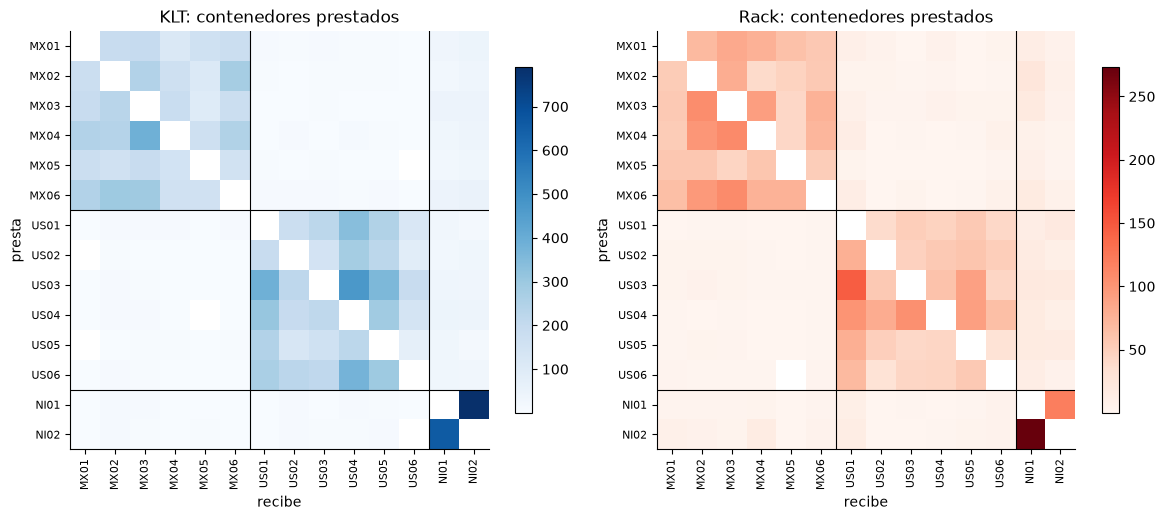

In [9]:
red = q("SELECT * FROM mart_red_prestamos")
plantas = q("SELECT planta, pais FROM plantas")
orden_pais = {"MX": 0, "US": 1, "NI": 2}
plantas = plantas.with_columns(pl.col("pais").replace_strict(orden_pais).alias("o")).sort(
    "o", "planta"
)
idx = {p: i for i, p in enumerate(plantas["planta"])}
etiquetas = [p.replace("PLNT_", "") for p in plantas["planta"]]
cortes = np.cumsum(plantas.group_by("o", maintain_order=True).len()["len"].to_list())[:-1] - 0.5

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
for ax, k in zip(axes, tipos, strict=True):
    m = np.zeros((len(idx), len(idx)))
    for r in red.filter(pl.col("tipo_material") == k).iter_rows(named=True):
        m[idx[r["planta_origen"]], idx[r["planta_destino"]]] += r["contenedores"]
    cmap = plt.get_cmap("Blues" if k == "KLT" else "Reds").copy()
    cmap.set_bad("white")
    im = ax.imshow(np.ma.masked_equal(m, 0), cmap=cmap)
    for c in cortes:
        ax.axhline(c, color="black", linewidth=0.8)
        ax.axvline(c, color="black", linewidth=0.8)
    ax.set_xticks(range(len(idx)), etiquetas, rotation=90, fontsize=8)
    ax.set_yticks(range(len(idx)), etiquetas, fontsize=8)
    ax.set_xlabel("recibe")
    ax.set_ylabel("presta")
    ax.set_title(f"{NOMBRE[k]}: contenedores prestados")
    fig.colorbar(im, ax=ax, shrink=0.75)
fig.tight_layout()
fig.savefig(IMG / "red_prestamos.png", dpi=150)
plt.show()

In [10]:
por_etapa = (
    red.group_by("tipo_material", "etapa")
    .agg(pl.len().alias("flujos"), pl.col("contenedores").sum(), pl.col("usd_flete").sum())
    .sort("tipo_material", "etapa")
)
e = {(r["tipo_material"], r["etapa"]): r for r in por_etapa.iter_rows(named=True)}

# La red reparte exactamente lo que int_prestamos presta (assert_red_cuadra en dbt).
for k in tipos:
    assert abs(e[(k, "mismo_pais")]["contenedores"] - b[k]["mismo_pais"]) < 1, k
    assert abs(e[(k, "otro_pais")]["contenedores"] - b[k]["otro_pais"]) < 1, k

top = red.sort("contenedores", descending=True).row(0, named=True)
_lineas = [
    f"- {NOMBRE[k]}: {e[(k, 'mismo_pais')]['flujos']} flujos dentro del país "
    f"({e[(k, 'mismo_pais')]['contenedores']:,.0f} contenedores, "
    f"{usd(e[(k, 'mismo_pais')]['usd_flete'])} "
    f"de flete) y {e[(k, 'otro_pais')]['flujos']} entre países "
    f"({e[(k, 'otro_pais')]['contenedores']:,.0f}, {usd(e[(k, 'otro_pais')]['usd_flete'])})."
    for k in tipos
]
_otro = sum(e[(k, "otro_pais")]["usd_flete"] for k in tipos)
_flete = sum(e[(k, et)]["usd_flete"] for k in tipos for et in ("mismo_pais", "otro_pais"))
_cont_otro = sum(e[(k, "otro_pais")]["contenedores"] for k in tipos)
_cont = sum(e[(k, et)]["contenedores"] for k in tipos for et in ("mismo_pais", "otro_pais"))
_lineas += [
    f"- Cruzar frontera mueve el {_cont_otro * 100 / _cont:.0f}% de los contenedores y cuesta el "
    f"{_otro * 100 / _flete:.0f}% del flete.",
    f"- El flujo más grande: {top['planta_origen']} → {top['planta_destino']}, "
    f"{top['contenedores']:,.0f} {NOMBRE[top['tipo_material']]}.",
]
display(Markdown("\n".join(_lineas)))

- KLT: 62 flujos dentro del país (14,369 contenedores, \$17,960 de flete) y 116 entre países (1,147, \$4,301).
- Rack: 62 flujos dentro del país (4,283 contenedores, \$38,544 de flete) y 120 entre países (582, \$15,711).
- Cruzar frontera mueve el 8% de los contenedores y cuesta el 26% del flete.
- El flujo más grande: PLNT_NI01 → PLNT_NI02, 789 KLT.

## 5. Dónde cae la brecha

Cada parte del plan trae un escenario del sintético: estable, arranque (+30%
desde la semana 4 a 8) o fin de serie (−50%) (ADR-022). Un material con al menos
una parte en arranque necesita más flota justo en las semanas en que la flota
proyectada ya bajó por merma y scrap.

In [11]:
por_arranque = q("""
    WITH arranque AS (
        SELECT i.planta, i.material, BOOL_OR(p.escenario = 'arranque') AS con_arranque
        FROM stg_instruccion_empaque i
        JOIN stg_partes p USING (planta, parte)
        GROUP BY ALL
    )
    SELECT b.tipo_material, COALESCE(a.con_arranque, false) AS con_arranque,
           COUNT(*)                                                AS materiales,
           SUM(b.deficit_pico)                                     AS deficit,
           SUM(b.usd_flete + b.usd_compra + b.usd_desechable)      AS usd_brecha
    FROM mart_brecha_flota b
    LEFT JOIN arranque a USING (planta, material)
    GROUP BY ALL
""")
_lineas = []
for k in tipos:
    t = por_arranque.filter(pl.col("tipo_material") == k)
    a = t.filter(pl.col("con_arranque")).row(0, named=True)
    _lineas.append(
        f"- {NOMBRE[k]}: los materiales con algún arranque son el "
        f"{a['materiales'] * 100 / t['materiales'].sum():.0f}% del total y cargan el "
        f"{a['deficit'] * 100 / t['deficit'].sum():.0f}% del déficit y el "
        f"{a['usd_brecha'] * 100 / t['usd_brecha'].sum():.0f}% del costo de la brecha."
    )
display(Markdown("\n".join(_lineas)))

- KLT: los materiales con algún arranque son el 42% del total y cargan el 64% del déficit y el 65% del costo de la brecha.
- Rack: los materiales con algún arranque son el 19% del total y cargan el 51% del déficit y el 57% del costo de la brecha.

El KLT cruza clientes y junta hasta ocho partes, así que casi la mitad de los
materiales tiene algún arranque; en el Rack, dedicado a un cliente, la brecha se
concentra en pocos materiales. Para un coordinador de RPL la lista de compra
sale de ahí: Rack con arranque en el programa del cliente.

La mezcla de escenarios es parámetro del generador. Barrerla pide regenerar el
plan, y eso queda para el simulador de Fase 4 (ADR-026).

## 6. Sensibilidad

Cada escenario de `escenarios_brecha` corre por la misma lógica que el base
(ADR-026). Rangos de los supuestos:

- Factor de costo de quiebre: 2 veces el desechable (1–3) y costo de capital:
  12% anual (8–15%) (ADR-025). Mueven la z.
- Lavado del KLT: 2 días hábiles (1–3) y reparación del Rack: 5.5% de lo
  recogido, 10 días hábiles (3–8%, 5–15 días) (ADR-017, ADR-019). Mueven el
  ciclo del plan: ±1.4 días naturales en KLT; −0.6 y +0.9 en Rack.
- Flete de préstamo: 5% del costo unitario dentro del país (3–8%) y 15% entre
  países (10–25%) (ADR-025). Lineal: se calcula aquí sobre `mart_brecha_flota`.

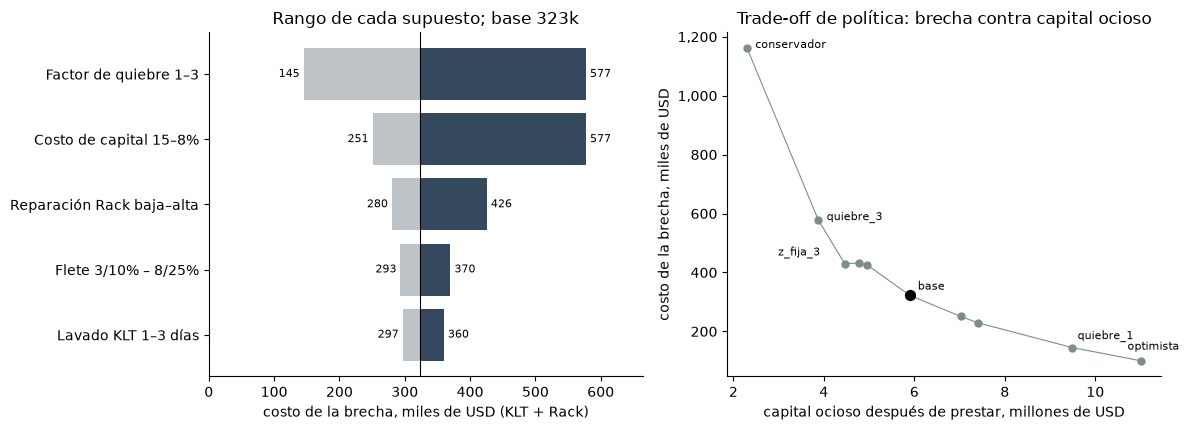

In [12]:
def total(escenario: str, col: str = "usd_brecha") -> float:
    return float(sens.filter(pl.col("escenario") == escenario)[col].sum())


# Flete lineal en sus dos porcentajes: usd = A × pct_mismo + B × pct_otro.
_f = q("""
    SELECT SUM(b.recibido_mismo_pais * t.costo_unitario_usd) / 100   AS a,
           SUM(b.recibido_otro_pais * t.costo_unitario_usd) / 100    AS b
    FROM mart_brecha_flota b
    JOIN mart_tco_comparativo t USING (planta, tipo_material)
""").row(0, named=True)
flete_base = sum(b_["usd_flete"] for b_ in b.values())
assert abs(_f["a"] * 5 + _f["b"] * 15 - flete_base) < 1, "El flete no se reproduce"
base_total = total("base")
assert abs(base_total - usd_brecha) < 1


def con_flete(mismo: float, otro: float) -> float:
    return base_total - flete_base + _f["a"] * mismo + _f["b"] * otro


rangos = [
    ("Factor de quiebre 1–3", total("quiebre_1"), total("quiebre_3")),
    ("Costo de capital 15–8%", total("capital_15"), total("capital_8")),
    ("Reparación Rack baja–alta", total("reparacion_rack_baja"), total("reparacion_rack_alta")),
    ("Lavado KLT 1–3 días", total("lavado_klt_1_dia"), total("lavado_klt_3_dias")),
    ("Flete 3/10% – 8/25%", con_flete(3, 10), con_flete(8, 25)),
]
rangos.sort(key=lambda r: r[2] - r[1])

politica = [
    "base",
    "quiebre_1",
    "quiebre_1_5",
    "quiebre_2_5",
    "quiebre_3",
    "capital_10",
    "capital_15",
    "optimista",
    "conservador",
    "z_fija_3",
]
frontera = (
    sens.filter(pl.col("escenario").is_in(politica))
    .group_by("escenario")
    .agg(pl.col("usd_brecha").sum(), pl.col("usd_capital_ocioso").sum())
    .sort("usd_capital_ocioso")
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))
for i, (_, bajo, alto) in enumerate(rangos):
    ax1.barh(i, (alto - base_total) / 1e3, left=base_total / 1e3, color="#34495e")
    ax1.barh(i, (bajo - base_total) / 1e3, left=base_total / 1e3, color="#bdc3c7")
    ax1.text(alto / 1e3, i, f" {alto / 1e3:,.0f}", va="center", fontsize=8)
    ax1.text(bajo / 1e3, i, f"{bajo / 1e3:,.0f} ", va="center", ha="right", fontsize=8)
ax1.axvline(base_total / 1e3, color="black", linewidth=0.8)
ax1.set_yticks(range(len(rangos)), [r[0] for r in rangos])
ax1.set_xlabel("costo de la brecha, miles de USD (KLT + Rack)")
ax1.set_title(f"Rango de cada supuesto; base {base_total / 1e3:,.0f}k")
ax1.set_xlim(0, max(r[2] for r in rangos) / 1e3 * 1.15)

ax2.plot(
    frontera["usd_capital_ocioso"] / 1e6,
    frontera["usd_brecha"] / 1e3,
    color=GRIS,
    linewidth=0.8,
    zorder=1,
)
# Etiqueta solo los extremos y las referencias; los puntos intermedios quedan sin nombre.
desplazamiento = {
    "base": (6, 4),
    "optimista": (-10, 8),
    "conservador": (6, 0),
    "quiebre_1": (4, 6),
    "quiebre_3": (6, 0),
    "z_fija_3": (-48, 6),
}
for r in frontera.iter_rows(named=True):
    es_base = r["escenario"] == "base"
    ax2.scatter(
        r["usd_capital_ocioso"] / 1e6,
        r["usd_brecha"] / 1e3,
        color="black" if es_base else GRIS,
        s=50 if es_base else 25,
        zorder=2,
    )
    if r["escenario"] in desplazamiento:
        ax2.annotate(
            r["escenario"],
            (r["usd_capital_ocioso"] / 1e6, r["usd_brecha"] / 1e3),
            textcoords="offset points",
            xytext=desplazamiento[r["escenario"]],
            fontsize=8,
        )
ax2.set_xlabel("capital ocioso después de prestar, millones de USD")
ax2.set_ylabel("costo de la brecha, miles de USD")
ax2.set_title("Trade-off de política: brecha contra capital ocioso")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
fig.tight_layout()
fig.savefig(IMG / "sensibilidad_brecha.png", dpi=150)
plt.show()

In [13]:
def escenario(e: str, k: str) -> dict:
    return sens.filter((pl.col("escenario") == e) & (pl.col("tipo_material") == k)).row(
        0, named=True
    )


mayor = max(rangos, key=lambda r: r[2] - r[1])
lav1, lav3 = escenario("lavado_klt_1_dia", "KLT"), escenario("lavado_klt_3_dias", "KLT")
costo_klt = float(
    q("SELECT MAX(costo_unitario_usd) AS c FROM mart_tco_comparativo WHERE tipo_material = 'KLT'")[
        "c"
    ][0]
)
libera = base["KLT"]["necesidad_semana_1"] - lav1["necesidad_semana_1"]
_lineas = [
    f"- El supuesto que más mueve la brecha es {mayor[0].lower()}: de {miles(mayor[1])} a "
    f"{miles(mayor[2])}.",
    "- La z solo depende del cociente entre factor de quiebre y costo de capital: capital al 8% "
    f"da la misma z que factor 3 ({escenario('capital_8', 'KLT')['z_servicio']:.2f} KLT y "
    f"{escenario('capital_8', 'RACK')['z_servicio']:.2f} Rack).",
    f"- Con z = 3 fija, la de ADR-021, cubrir la brecha costaría {miles(total('z_fija_3'))} y "
    "quedarían "
    f"{millones(total('z_fija_3', 'usd_capital_ocioso'))} de capital ocioso.",
    f"- Optimista (factor 1, capital 15%): {miles(total('optimista'))} de brecha y "
    f"{millones(total('optimista', 'usd_capital_ocioso'))} ociosos. Conservador (factor 3, capital "
    f"8%): {miles(total('conservador'))} y {millones(total('conservador', 'usd_capital_ocioso'))}. "
    "Bajar la brecha se paga con flota parada; la curva de la derecha es la decisión.",
    f"- Un día hábil de lavado de KLT vale {libera:,} contenedores de necesidad, "
    f"{millones(libera * costo_klt)} a costo unitario. Con 3 días la brecha KLT pasa de "
    f"{miles(base['KLT']['usd_brecha'])} a {miles(lav3['usd_brecha'])}; con 1, a "
    f"{miles(lav1['usd_brecha'])}. Es la única palanca del análisis que no compra flota: la "
    "libera.",
    "- La holgura de la flota inicial no lleva escenario: mueve la flota, no la necesidad, y su "
    "efecto es el capital ocioso que ya está a la vista.",
]
display(Markdown("\n".join(_lineas)))

- El supuesto que más mueve la brecha es factor de quiebre 1–3: de \$145k a \$577k.
- La z solo depende del cociente entre factor de quiebre y costo de capital: capital al 8% da la misma z que factor 3 (2.95 KLT y 3.20 Rack).
- Con z = 3 fija, la de ADR-021, cubrir la brecha costaría \$429k y quedarían \$4.46M de capital ocioso.
- Optimista (factor 1, capital 15%): \$100k de brecha y \$11.02M ociosos. Conservador (factor 3, capital 8%): \$1,162k y \$2.30M. Bajar la brecha se paga con flota parada; la curva de la derecha es la decisión.
- Un día hábil de lavado de KLT vale 31,962 contenedores de necesidad, \$0.80M a costo unitario. Con 3 días la brecha KLT pasa de \$66k a \$103k; con 1, a \$40k. Es la única palanca del análisis que no compra flota: la libera.
- La holgura de la flota inicial no lleva escenario: mueve la flota, no la necesidad, y su efecto es el capital ocioso que ya está a la vista.

## 7. Resumen ejecutivo

In [14]:
def fila(etiqueta: str, fmt) -> str:
    return f"| {etiqueta} | {fmt('KLT')} | {fmt('RACK')} |"


_tabla = "\n".join(
    [
        "| | KLT | Rack |",
        "|---|---:|---:|",
        fila("z por costo", lambda k: f"{base[k]['z_servicio']:.2f}"),
        fila("Necesidad semana 1", lambda k: f"{base[k]['necesidad_semana_1']:,}"),
        fila("Flota proyectada semana 12", lambda k: f"{n12[k]['flota']:,.0f}"),
        fila("Materiales en déficit", lambda k: f"{b[k]['materiales']:,}"),
        fila("Déficit pico", lambda k: f"{b[k]['deficit']:,.0f}"),
        fila("Préstamo", lambda k: f"{b[k]['mismo_pais'] + b[k]['otro_pais']:,.0f}"),
        fila("Compra", lambda k: f"{b[k]['compra']:,}"),
        fila("Viajes en desechable", lambda k: f"{b[k]['viajes_desechable']:,.0f}"),
        fila("Costo de la brecha", lambda k: usd(b[k]["usd_brecha"])),
        fila("Capital ocioso", lambda k: millones(b[k]["usd_capital_ocioso"])),
    ]
)

display(
    Markdown(f"""
{_tabla}

- Cubrir el plan de 12 semanas cuesta {usd(usd_brecha)}: el préstamo entre plantas
  resuelve el {_cubre:.1f}% del déficit y el resto es compra y desechable.
- Después de prestar quedan {millones(usd_ocioso)} de flota parada. El problema de
  la red es de distribución, no de tamaño.
- La brecha se concentra en materiales con arranques en el programa del cliente.
- El supuesto que más mueve el resultado es {mayor[0].lower()} ({miles(mayor[1])} a
  {miles(mayor[2])}); el lavado del KLT es la palanca operativa: un día menos
  libera {libera:,} contenedores.
""")
)


| | KLT | Rack |
|---|---:|---:|
| z por costo | 2.70 | 2.90 |
| Necesidad semana 1 | 1,098,502 | 199,087 |
| Flota proyectada semana 12 | 1,245,651 | 217,588 |
| Materiales en déficit | 972 | 607 |
| Déficit pico | 17,066 | 5,608 |
| Préstamo | 15,516 | 4,865 |
| Compra | 1,592 | 790 |
| Viajes en desechable | 793 | 1,346 |
| Costo de la brecha | \$65,630 | \$257,046 |
| Capital ocioso | \$3.23M | \$2.67M |

- Cubrir el plan de 12 semanas cuesta \$322,675: el préstamo entre plantas
  resuelve el 89.9% del déficit y el resto es compra y desechable.
- Después de prestar quedan \$5.89M de flota parada. El problema de
  la red es de distribución, no de tamaño.
- La brecha se concentra en materiales con arranques en el programa del cliente.
- El supuesto que más mueve el resultado es factor de quiebre 1–3 (\$145k a
  \$577k); el lavado del KLT es la palanca operativa: un día menos
  libera 31,962 contenedores.


In [15]:
con.close()